**K Choice and Playstyles Clustering**

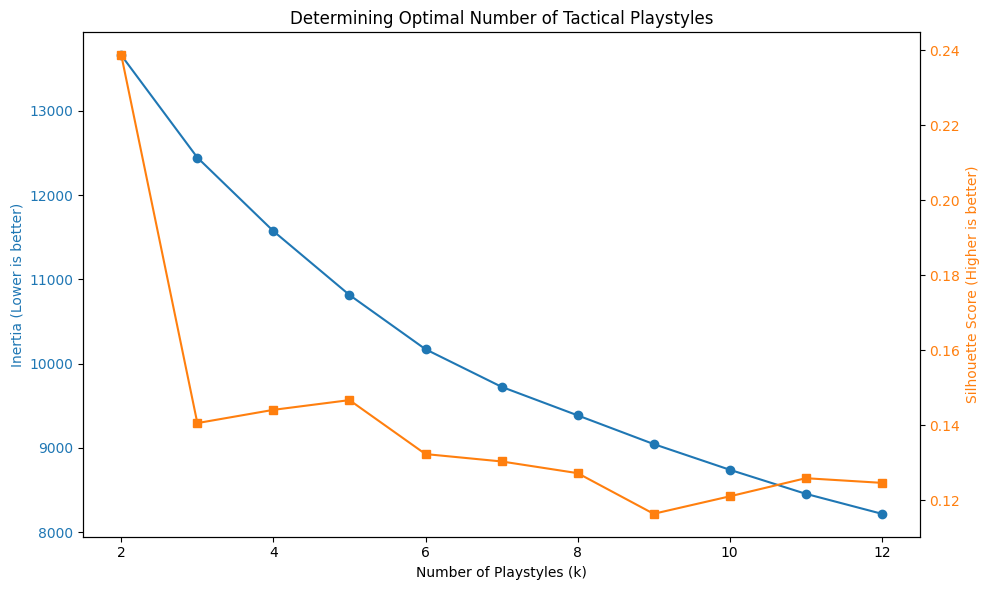

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
def evaluate_optimal_clusters(df, max_k=12):
    """
    Calculates the Elbow Curve (Inertia) and Silhouette Scores to 
    mathematically determine the optimal number of tactical playstyles.
    """
    
    style_features = [
        'passes_rolling', 'shots_rolling', 'xg_rolling', 'pressures_rolling', 
        'ball_recoveries_rolling', 'interceptions_rolling', 'possession_events_rolling', 
        'pressing_efficiency_rolling', 'shot_quality_rolling', 'directness_index_rolling', 
        'chaos_index_rolling', 'xg_volatility', 'pressures_volatility'
    ]
    
    df_clustering = df.dropna(subset=style_features).copy()
    
    scaler = StandardScaler()
    scaled_data = scaler.fit_transform(df_clustering[style_features])
    
    inertias = []
    silhouette_scores = []
    k_values = range(2, max_k + 1)
    
    for k in k_values:
        kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
        labels = kmeans.fit_predict(scaled_data)
        
        inertias.append(kmeans.inertia_)
        silhouette_scores.append(silhouette_score(scaled_data, labels))
        
    # Plotting the results
    fig, ax1 = plt.subplots(figsize=(10, 6))

    # Plot Elbow Curve (Inertia)
    color = 'tab:blue'
    ax1.set_xlabel('Number of Playstyles (k)')
    ax1.set_ylabel('Inertia (Lower is better)', color=color)
    ax1.plot(k_values, inertias, marker='o', color=color)
    ax1.tick_params(axis='y', labelcolor=color)

    # Plot Silhouette Score
    ax2 = ax1.twinx()  
    color = 'tab:orange'
    ax2.set_ylabel('Silhouette Score (Higher is better)', color=color)
    ax2.plot(k_values, silhouette_scores, marker='s', color=color)
    ax2.tick_params(axis='y', labelcolor=color)

    plt.title('Determining Optimal Number of Tactical Playstyles')
    fig.tight_layout()  
    plt.show()

final_prematch_df = pd.read_csv('Final_Data.csv')
evaluate_optimal_clusters(final_prematch_df)

**Data Tweaks After Clustering**

In [5]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.cluster import KMeans

# Load the Engineered Data
df = pd.read_csv('Final_Data.csv')

# Re-apply the 8-Cluster K-Means (to assign the Playstyle ID to every row)
style_features = [
    'passes_rolling', 'shots_rolling', 'xg_rolling', 'pressures_rolling', 
    'ball_recoveries_rolling', 'interceptions_rolling', 'possession_events_rolling', 
    'pressing_efficiency_rolling', 'shot_quality_rolling', 'directness_index_rolling', 
    'chaos_index_rolling', 'xg_volatility', 'pressures_volatility'
]

# Drop any remaining NaNs to ensure K-Means works perfectly
df_clean = df.dropna(subset=style_features).copy()

# Scale and Predict Clusters
scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_clean[style_features])
kmeans = KMeans(n_clusters=8, random_state=42, n_init=10)
df_clean['Tactical_Cluster'] = kmeans.fit_predict(scaled_data)


# Split into Home and Away datasets using the 'is_home' column
df_home = df_clean[df_clean['is_home'] == 1].copy()
df_away = df_clean[df_clean['is_home'] == 0].copy()

# Select the features the ML model actually needs to see
model_features = ['match_id', 'starting_formation','last_formation', 'Tactical_Cluster', 'days_rest', 'xg_momentum'] + style_features

# Add 'home_' prefix to home stats and 'away_' prefix to away stats
# We keep 'result' on the home side as our target variable
df_home = df_home[model_features + ['result']].add_prefix('home_').rename(columns={'home_match_id': 'match_id', 'home_result': 'match_result'})
df_away = df_away[model_features].add_prefix('away_').rename(columns={'away_match_id': 'match_id'})

# Merge them together on the match_id
df_matchups = pd.merge(df_home, df_away, on='match_id', how='inner')

# Drop any rows where the merge created NaNs
df_matchups = df_matchups.dropna().reset_index(drop=True)

# 4. Encode the Target Variable
le = LabelEncoder()
# Converts the string results (e.g., 'home_win', 'draw', 'away_win') into 0, 1, 2
df_matchups['target'] = le.fit_transform(df_matchups['match_result'])

print(f"Matchups successfully built! Final dataset contains {len(df_matchups)} head-to-head matches.")
print(f"Target classes encoded as: {dict(zip(le.classes_, le.transform(le.classes_)))}")

# Preview the head-to-head structure
display_cols = ['match_id', 'home_Tactical_Cluster', 'away_Tactical_Cluster', 'match_result', 'target']
print("\nSample of the Head-to-Head grid:")
print(df_matchups[display_cols].head())

Matchups successfully built! Final dataset contains 663 head-to-head matches.
Target classes encoded as: {'away_win': np.int64(0), 'draw': np.int64(1), 'home_win': np.int64(2)}

Sample of the Head-to-Head grid:
   match_id  home_Tactical_Cluster  away_Tactical_Cluster match_result  target
0   3920402                      5                      5         draw       1
1   3920414                      7                      5     home_win       2
2   3922237                      7                      6     home_win       2
3   3857289                      1                      5     home_win       2
4   3869151                      1                      5     home_win       2


In [5]:
df_matchups

,match_id,home_starting_formation,home_last_formation,home_Tactical_Cluster,home_days_rest,home_xg_momentum,home_passes_rolling,home_shots_rolling,home_xg_rolling,home_pressures_rolling,...,away_ball_recoveries_rolling,away_interceptions_rolling,away_possession_events_rolling,away_pressing_efficiency_rolling,away_shot_quality_rolling,away_directness_index_rolling,away_chaos_index_rolling,away_xg_volatility,away_pressures_volatility,target
0,3920402,4231,442.0,5,5.0,0.000000,589.000000,16.000000,0.696929,101.000000,...,48.000000,12.0,1652.000000,0.428571,0.103332,0.276634,30.000000,0.000000,0.000000,1
1,3920414,4141,4231.0,7,3.0,0.000000,320.000000,13.500000,1.620712,170.000000,...,47.500000,9.5,1350.500000,0.410119,0.141594,0.265105,31.500000,0.086503,5.656854,2
2,3922237,433,4411.0,7,4.0,0.000000,348.333333,11.000000,1.375230,167.666667,...,58.000000,11.0,1290.333333,0.347861,0.132407,0.250863,14.333333,0.577706,49.084960,2
3,3857289,442,352.0,1,4.0,0.000000,646.000000,15.000000,2.491633,107.000000,...,49.000000,8.0,1822.000000,0.510417,0.048103,0.298573,20.000000,0.000000,0.000000,2
4,3869151,433,352.0,1,3.0,0.000000,707.333333,14.666667,1.964499,101.333333,...,43.333333,11.0,1437.666667,0.392855,0.059810,0.284432,19.000000,0.076345,14.000000,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
658,19802,442,442.0,6,14.0,-0.169520,292.010000,6.000000,0.485595,253.190000,...,65.780000,13.4,1594.800000,0.429889,0.099007,0.254926,11.400000,0.778660,72.086826,1
659,19758,442,4411.0,6,14.0,-0.129529,289.210000,5.200000,0.443597,214.800000,...,66.600000,5.6,1709.000000,0.456858,0.137365,0.270893,14.600000,0.838601,44.424093,0
660,19822,442,442.0,6,13.0,-0.105464,272.410000,7.200000,0.518570,194.800000,...,62.000000,7.4,1910.000000,0.462822,0.091440,0.278553,12.800000,0.367735,43.008139,0
661,3920406,4141,41212.0,5,4.0,0.000000,409.000000,3.000000,0.096433,104.000000,...,41.000000,10.0,1645.000000,0.341667,0.005963,0.285714,33.000000,0.000000,0.000000,1


In [6]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.metrics import accuracy_score, f1_score, log_loss
from sklearn.preprocessing import StandardScaler
import warnings
warnings.filterwarnings('ignore')


# Assuming df_matchups is already in memory from the merge step
y = df_matchups['target'].values
X = df_matchups.drop(columns=['match_id', 'match_result', 'target'])
X = pd.get_dummies(X, drop_first=True) # Handle categorical variables

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

# Global storage for results
results = []
best_estimators = {}

# Helper function to evaluate and save
def evaluate_and_save(name, model):
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)
    acc = accuracy_score(y_test, y_pred)
    f1 = f1_score(y_test, y_pred, average='weighted')
    loss = log_loss(y_test, y_proba)
    
    results.append({"Model": name, "Accuracy": round(acc * 100, 2), "Log Loss": round(loss, 4)})
    best_estimators[name] = model
    print(f"[{name}] -> Accuracy: {acc*100:.2f}% | Log Loss: {loss:.4f}")


**Models**

**Logistic Regression**

In [7]:
from sklearn.linear_model import LogisticRegression


log_param = {'C': [0.01, 0.1, 1, 10]}
log_search = RandomizedSearchCV(LogisticRegression(max_iter=1000, random_state=42), log_param, n_iter=4, cv=5, scoring='neg_log_loss', random_state=42)
log_search.fit(X_train_scaled, y_train)

evaluate_and_save("Logistic Regression", log_search.best_estimator_)

[Logistic Regression] -> Accuracy: 55.64% | Log Loss: 0.9207


**SVM**

In [8]:
from sklearn.svm import SVC


# C controls the penalty for misclassification, gamma controls the influence of a single point
svm_param = {'C': [0.1, 1, 10], 'gamma': ['scale', 'auto', 0.1, 0.01]}

# We use probability=True so it can calculate Log Loss
svm_search = RandomizedSearchCV(
    SVC(kernel='rbf', probability=True, random_state=42), 
    svm_param, 
    n_iter=5, 
    cv=5, 
    scoring='neg_log_loss', 
    n_jobs=-1, 
    random_state=42
)
svm_search.fit(X_train_scaled, y_train)

evaluate_and_save("SVM (RBF Kernel)", svm_search.best_estimator_)

[SVM (RBF Kernel)] -> Accuracy: 53.38% | Log Loss: 0.9575


**KNN**

In [9]:
from sklearn.neighbors import KNeighborsClassifier

knn_param = {
    'n_neighbors': [3, 5, 7, 9, 11], 
    'weights': ['uniform', 'distance'],
    'p': [1, 2] # 1 is Manhattan distance, 2 is Euclidean
}

knn_search = RandomizedSearchCV(
    KNeighborsClassifier(), knn_param, n_iter=5, cv=5, 
    scoring='neg_log_loss', n_jobs=-1, random_state=42
)
knn_search.fit(X_train_scaled, y_train)

evaluate_and_save("K-Nearest Neighbors", knn_search.best_estimator_)

[K-Nearest Neighbors] -> Accuracy: 51.13% | Log Loss: 1.2392


**Random Forest**

In [10]:
from sklearn.ensemble import RandomForestClassifier


rf_param = {'n_estimators': [100, 200], 'max_depth': [None, 5, 10], 'min_samples_split': [2, 5]}
rf_search = RandomizedSearchCV(RandomForestClassifier(random_state=42), rf_param, n_iter=5, cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42)
rf_search.fit(X_train_scaled, y_train)

evaluate_and_save("Random Forest", rf_search.best_estimator_)

[Random Forest] -> Accuracy: 55.64% | Log Loss: 0.9414


**Extra Trees**

In [7]:
from sklearn.ensemble import ExtraTreesClassifier

et_param = {
    'n_estimators': [100, 200], 
    'max_depth': [None, 5, 10], 
    'min_samples_split': [2, 5]
}

et_search = RandomizedSearchCV(
    ExtraTreesClassifier(random_state=42), et_param, 
    n_iter=5, cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42
)
et_search.fit(X_train_scaled, y_train)

evaluate_and_save("Extra Trees", et_search.best_estimator_)

[Extra Trees] -> Accuracy: 59.40% | Log Loss: 0.9340


**Bagging**

In [12]:
from sklearn.ensemble import BaggingClassifier

bag_param = {
    'n_estimators': [10, 50, 100], 
    'max_samples': [0.5, 0.8, 1.0],
    'max_features': [0.8, 1.0]
}

bag_search = RandomizedSearchCV(
    BaggingClassifier(random_state=42), bag_param, 
    n_iter=5, cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42
)
bag_search.fit(X_train_scaled, y_train)

evaluate_and_save("Bagging Classifier", bag_search.best_estimator_)

[Bagging Classifier] -> Accuracy: 53.38% | Log Loss: 0.9625


**XGBoost**

In [7]:
import xgboost as xgb


xgb_param = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [3, 5, 7]}
xgb_search = RandomizedSearchCV(xgb.XGBClassifier(objective='multi:softprob', random_state=42), xgb_param, n_iter=5, cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42)
xgb_search.fit(X_train_scaled, y_train)

evaluate_and_save("XGBoost", xgb_search.best_estimator_)

[XGBoost] -> Accuracy: 56.39% | Log Loss: 0.9271


In [9]:
import xgboost as xgb
from sklearn.utils.class_weight import compute_sample_weight
from sklearn.model_selection import RandomizedSearchCV

# 1. Calculate the dynamic class weights based on your target variable
# This tells the math to heavily penalize missing a 'Draw'
sample_weights = compute_sample_weight(class_weight='balanced', y=y_train)

# 2. Define your hyperparameter grid
xgb_param = {
    'n_estimators': [100, 200], 
    'learning_rate': [0.01, 0.05, 0.1], 
    'max_depth': [3, 5, 7]
}

# 3. Set up the RandomizedSearchCV
xgb_search = RandomizedSearchCV(
    xgb.XGBClassifier(objective='multi:softprob', random_state=42), 
    xgb_param, 
    n_iter=5, 
    cv=5, 
    scoring='neg_log_loss', 
    n_jobs=-1, 
    random_state=42
)

# 4. FIT WITH WEIGHTS (This is the magic step!)
# RandomizedSearchCV will pass these weights down to the XGBoost algorithm
xgb_search.fit(X_train_scaled, y_train, sample_weight=sample_weights)

# 5. Save the winning model to your deployment folder
evaluate_and_save("XGBoost", xgb_search.best_estimator_)

[XGBoost] -> Accuracy: 48.87% | Log Loss: 0.9836


**AdaBoost**

In [14]:
from sklearn.ensemble import AdaBoostClassifier

ada_param = {
    'n_estimators': [50, 100, 200], 
    'learning_rate': [0.01, 0.1, 1.0]
}

ada_search = RandomizedSearchCV(
    AdaBoostClassifier(random_state=42), ada_param, 
    n_iter=5, cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42
)
ada_search.fit(X_train_scaled, y_train)

evaluate_and_save("AdaBoost", ada_search.best_estimator_)

[AdaBoost] -> Accuracy: 53.38% | Log Loss: 1.0094


**Gradient Boosting**

In [15]:
from sklearn.ensemble import GradientBoostingClassifier

gb_param = {
    'n_estimators': [100, 200], 
    'learning_rate': [0.01, 0.05, 0.1], 
    'max_depth': [3, 5, 7]
}

gb_search = RandomizedSearchCV(
    GradientBoostingClassifier(random_state=42), gb_param, 
    n_iter=5, cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42
)
gb_search.fit(X_train_scaled, y_train)

evaluate_and_save("Gradient Boosting", gb_search.best_estimator_)

[Gradient Boosting] -> Accuracy: 55.64% | Log Loss: 0.9393


**LightGBM**

In [16]:
import lightgbm as lgb


lgb_param = {'n_estimators': [100, 200], 'learning_rate': [0.01, 0.05, 0.1], 'max_depth': [3, 5, 7]}
lgb_search = RandomizedSearchCV(lgb.LGBMClassifier(random_state=42, verbose=-1), lgb_param, n_iter=5, cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42)
lgb_search.fit(X_train_scaled, y_train)

evaluate_and_save("LightGBM", lgb_search.best_estimator_) 
print(lgb_search.best_params_) 

[LightGBM] -> Accuracy: 57.14% | Log Loss: 0.9345
{'n_estimators': 200, 'max_depth': 3, 'learning_rate': 0.01}


**CatBoost**

In [ ]:
from catboost import CatBoostClassifier


cat_param = {'iterations': [100, 200], 'learning_rate': [0.01, 0.05, 0.1], 'depth': [4, 6]}
cat_search = RandomizedSearchCV(CatBoostClassifier(random_state=42, verbose=0), cat_param, n_iter=5, cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42)
cat_search.fit(X_train_scaled, y_train)

evaluate_and_save("CatBoost", cat_search.best_estimator_)

[CatBoost] -> Accuracy: 60.90% | Log Loss: 0.9289


**ANN**

In [18]:
from sklearn.neural_network import MLPClassifier


mlp_param = {'hidden_layer_sizes': [(64,), (64, 32)], 'activation': ['relu', 'tanh'], 'alpha': [0.0001, 0.01]}
mlp_search = RandomizedSearchCV(MLPClassifier(max_iter=1000, early_stopping=True, random_state=42), mlp_param, n_iter=5, cv=5, scoring='neg_log_loss', n_jobs=-1, random_state=42)
mlp_search.fit(X_train_scaled, y_train)

evaluate_and_save("Artificial Neural Network", mlp_search.best_estimator_)

[Artificial Neural Network] -> Accuracy: 53.38% | Log Loss: 0.9679


**Tabpfn**

In [19]:
from tabpfn import TabPFNClassifier

# TabPFN does not need hyperparameter tuning, it is a zero-shot foundation model
tabpfn_model = TabPFNClassifier()
tabpfn_model.fit(X_train, y_train)

evaluate_and_save("TabPFN", tabpfn_model)

[TabPFN] -> Accuracy: 41.35% | Log Loss: 1.0887


**Evaluation**

In [ ]:
import numpy as np
import pandas as pd
from scipy import stats
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, f1_score, roc_auc_score

def ci95(vals):
    arr = np.array(vals)
    m, se = np.mean(arr), stats.sem(arr)
    lo, hi = stats.t.interval(0.95, len(arr)-1, loc=m, scale=se)
    return float(m), float(lo), float(hi), float(np.std(arr))

# Define the folds
skf = StratifiedKFold(n_splits=10, shuffle=True, random_state=42)

# Instantiate the models directly so we can extract feature importance later
models_cv = {
    'CatBoost': CatBoostClassifier(iterations=200, learning_rate=0.05, depth=6, random_state=42, verbose=0),
    'XGBoost': xgb.XGBClassifier(objective='multi:softprob', n_estimators=200, learning_rate=0.05, max_depth=6, random_state=42, verbosity=0),
    'ExtraTrees': ExtraTreesClassifier(n_estimators=100, random_state=42),
}

cv_summary = []
fold_details = []


print("CROSS-VALIDATION FOLD-BY-FOLD ANALYSIS ")

for name, model in models_cv.items():
    print(f"\n Evaluating {name} ")
    accs, aucs, f1s = [], [], []
    

    for fold, (tr, te) in enumerate(skf.split(X_train_scaled, y_train), 1):
        
        # Fit on 9 folds
        model.fit(X_train_scaled[tr], y_train[tr])
        
        # Predict on the 1 validation fold
        yp = model.predict(X_train_scaled[te])
        if hasattr(yp, 'flatten'): yp = yp.flatten()
        ypr = model.predict_proba(X_train_scaled[te])
        
        # Calculate metrics for THIS specific fold
        acc = accuracy_score(y_train[te], yp)
        f1 = f1_score(y_train[te], yp, average='weighted', zero_division=0)
        try: 
            auc = roc_auc_score(y_train[te], ypr, multi_class='ovr', average='weighted')
        except: 
            auc = np.nan
            
        accs.append(acc)
        aucs.append(auc)
        f1s.append(f1)
        
        print(f"  Fold {fold:2d}: Acc = {acc*100:.2f}% | AUC = {auc:.3f} | F1 = {f1:.3f}")

    # Calculate statistics across all 10 folds
    am, alo, ahi, asd = ci95(accs)
    um, ulo, uhi, usd = ci95(aucs)
    fm, flo, fhi, fsd = ci95(f1s)
    
   
    model.fit(X_train_scaled, y_train)
        
    cv_summary.append({
        'Model': name,
        'CV Mean Acc': f"{am*100:.2f}%",
        'CV Mean AUC': f"{um:.3f}"
    })


CROSS-VALIDATION FOLD-BY-FOLD ANALYSIS 

 Evaluating CatBoost 
  Fold  1: Acc = 52.83% | AUC = 0.647 | F1 = 0.511
  Fold  2: Acc = 58.49% | AUC = 0.689 | F1 = 0.557
  Fold  3: Acc = 64.15% | AUC = 0.750 | F1 = 0.605
  Fold  4: Acc = 49.06% | AUC = 0.665 | F1 = 0.427
  Fold  5: Acc = 52.83% | AUC = 0.700 | F1 = 0.471
  Fold  6: Acc = 47.17% | AUC = 0.661 | F1 = 0.439
  Fold  7: Acc = 54.72% | AUC = 0.668 | F1 = 0.504
  Fold  8: Acc = 54.72% | AUC = 0.688 | F1 = 0.488
  Fold  9: Acc = 52.83% | AUC = 0.696 | F1 = 0.488
  Fold 10: Acc = 64.15% | AUC = 0.691 | F1 = 0.587

 Evaluating XGBoost 
  Fold  1: Acc = 41.51% | AUC = 0.631 | F1 = 0.391
  Fold  2: Acc = 58.49% | AUC = 0.715 | F1 = 0.569
  Fold  3: Acc = 49.06% | AUC = 0.701 | F1 = 0.478
  Fold  4: Acc = 47.17% | AUC = 0.634 | F1 = 0.436
  Fold  5: Acc = 45.28% | AUC = 0.650 | F1 = 0.415
  Fold  6: Acc = 41.51% | AUC = 0.639 | F1 = 0.385
  Fold  7: Acc = 50.94% | AUC = 0.645 | F1 = 0.495
  Fold  8: Acc = 50.94% | AUC = 0.666 | F1 = 0.4

In [21]:
import pandas as pd
from sklearn.metrics import accuracy_score, f1_score, log_loss, precision_score, recall_score, roc_auc_score


extended_results = []

# Loop through the models you already trained and saved
for name, model in best_estimators.items():
    
    # Get predictions on the holdout test set
    y_pred = model.predict(X_test_scaled)
    y_proba = model.predict_proba(X_test_scaled)
    
    # 1. Base Metrics
    acc = accuracy_score(y_test, y_pred)
    logloss = log_loss(y_test, y_proba)
    
    # 2. Weighted Classification Metrics (Accounts for class imbalance like draws)
    # zero_division=0 prevents warnings if a model entirely ignores a class
    precision = precision_score(y_test, y_pred, average='weighted', zero_division=0)
    recall = recall_score(y_test, y_pred, average='weighted', zero_division=0)
    f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)
    
    # 3. ROC-AUC for Multi-Class (One-vs-Rest strategy)
    roc_auc = roc_auc_score(y_test, y_proba, multi_class='ovr', average='weighted')
    
    # Store the results
    extended_results.append({
        "Model": name,
        "Accuracy": round(acc * 100, 2),
        "Log Loss": round(logloss, 4),
        "ROC-AUC": round(roc_auc, 4),
        "F1-Score": round(f1, 4),
        "Precision": round(precision, 4),
        "Recall": round(recall, 4)
    })

# Create a beautifully formatted DataFrame
extended_df = pd.DataFrame(extended_results)

# Sort by ROC-AUC (Highest is best) as it's a great holistic metric
extended_df = extended_df.sort_values(by="ROC-AUC", ascending=False).reset_index(drop=True)

print("\n COMPREHENSIVE MODEL COMPARISON (on test set) ")
print(extended_df.to_string())


 COMPREHENSIVE MODEL COMPARISON (on test set) 
                        Model  Accuracy  Log Loss  ROC-AUC  F1-Score  Precision  Recall
0                     XGBoost     56.39    0.9271   0.7406    0.5186     0.5536  0.5639
1                 Extra Trees     59.40    0.9340   0.7325    0.5402     0.6112  0.5940
2                    CatBoost     60.90    0.9289   0.7268    0.5817     0.5870  0.6090
3         Logistic Regression     55.64    0.9207   0.7244    0.4894     0.4385  0.5564
4           Gradient Boosting     55.64    0.9393   0.7198    0.5126     0.5231  0.5564
5                    LightGBM     57.14    0.9345   0.7196    0.5173     0.5239  0.5714
6               Random Forest     55.64    0.9414   0.7122    0.4890     0.4457  0.5564
7            SVM (RBF Kernel)     53.38    0.9575   0.7090    0.4429     0.4268  0.5338
8          Bagging Classifier     53.38    0.9625   0.7006    0.5146     0.5158  0.5338
9   Artificial Neural Network     53.38    0.9679   0.6943    0.4820    

## Feature Importance


 NUMERICAL FEATURE IMPORTANCE (CATBOOST) 
                             Feature  Importance Score
0     home_possession_events_rolling          6.154437
1          home_shot_quality_rolling          4.174460
2                home_passes_rolling          4.053277
3   away_pressing_efficiency_rolling          3.721945
4                home_last_formation          3.702217
5      home_directness_index_rolling          3.520381
6                 home_xg_volatility          3.486510
7                away_passes_rolling          3.328637
8              home_Tactical_Cluster          3.243756
9          away_pressures_volatility          3.184516
10          home_chaos_index_rolling          3.063670
11        home_interceptions_rolling          2.915975
12                   home_xg_rolling          2.862533
13               away_last_formation          2.816832
14        away_interceptions_rolling          2.805837


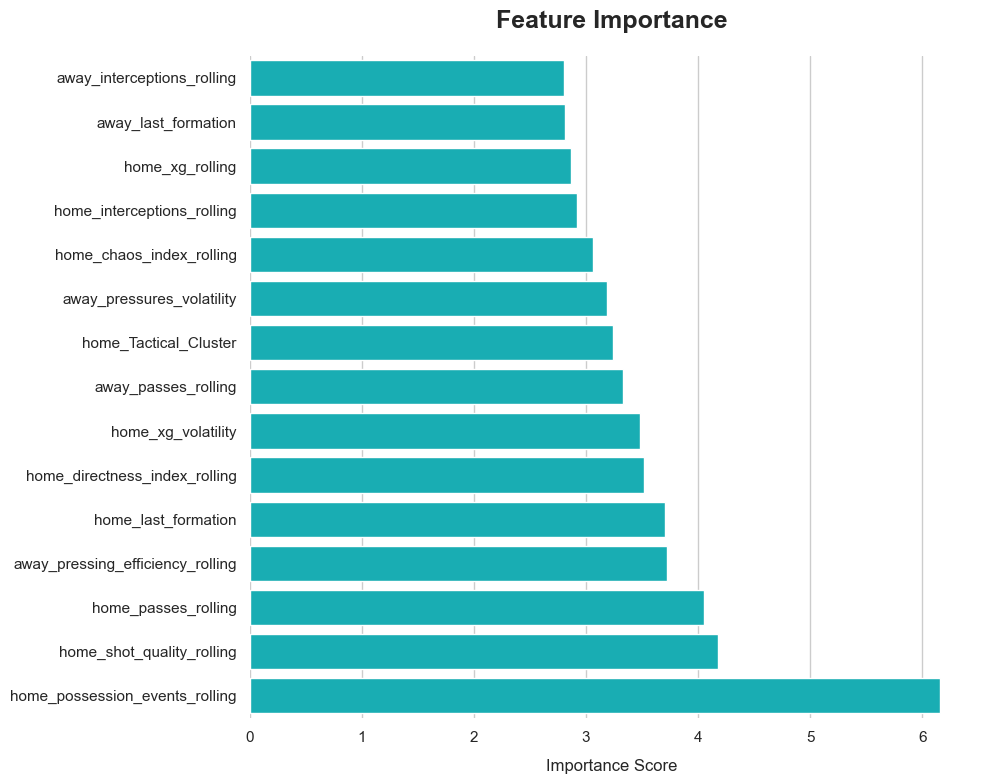

In [23]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

print("\n NUMERICAL FEATURE IMPORTANCE (CATBOOST) ")

cat_model = models_cv['CatBoost']
importances = cat_model.get_feature_importance()

# Retrieve feature names (assuming they are in X_train.columns, adjust if your var is named differently)
feature_names = X_train.columns if hasattr(X_train, 'columns') else [f"Feature_{i}" for i in range(len(importances))]

feat_imp_df = pd.DataFrame({
    'Feature': feature_names,
    'Importance Score': importances
}).sort_values(by='Importance Score', ascending=False).reset_index(drop=True)

# Print the top 15 most important features driving the tactical predictions
print(feat_imp_df.head(15).to_string())


# 1. Set up the visual style
plt.figure(figsize=(10, 8))
sns.set_theme(style="whitegrid") # Automatically adds the vertical grid lines

# Get the top 15 features and reverse them so the highest is at the top of the chart
top_15_features = feat_imp_df['Feature'].head(15)[::-1]
top_15_scores = feat_imp_df['Importance Score'].head(15)[::-1]

# 2. Draw the horizontal bar chart
# Using the cyan/teal color to match your reference image
ax = sns.barplot(x=top_15_scores, y=top_15_features, color="#00C4CC") 

# 3. Format the labels and title
plt.title('Feature Importance', fontsize=18, fontweight='bold', pad=20)
plt.xlabel('Importance Score', fontsize=12, labelpad=10)
plt.ylabel('') # Leave y-axis blank just like the reference

# Clean up the tick fonts for readability
plt.yticks(fontsize=11)
plt.xticks(fontsize=11)

# 4. Remove the outer bounding box for a modern, borderless look
sns.despine(left=True, bottom=True)
plt.tight_layout() # Adjust layout to prevent clipping
plt.show()

## Importing the models used for the engine

In [ ]:
import joblib


# 1. Save the Scikit-Learn objects using joblib
joblib.dump(scaler, 'sim2win_scaler.pkl')
joblib.dump(kmeans, 'sim2win_kmeans.pkl')

# 2. Save the Feature Columns list
# (Assuming X_train is your dataframe before scaling)
feature_cols = X_train.columns.tolist() if hasattr(X_train, 'columns') else X_train_scaled_columns
joblib.dump(feature_cols, 'sim2win_columns.pkl')

# 3. Save XGBoost using its native format (safer than pickle for XGBoost)
# Assuming 'xgb_search.best_estimator_' is your final model
xgb_model = models_cv['XGBoost'] # Or wherever your final model is stored
xgb_model.save_model('sim2win_xgb.json')

# Saving CatBoost using its native format
cat_model = models_cv['CatBoost']
cat_model.save_model('sim2win_catboost.cbm')

print("All models successfully saved to disk!")

All models successfully saved to disk!
